In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/heart_disease_dataset.csv"

df = pd.read_csv(url)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,state
0,63.0,M,tap,145.0,233.0,yes,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,M,asp,160.0,286.0,no,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,M,asp,120.0,229.0,no,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,M,nap,130.0,250.0,no,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,F,aap,130.0,204.0,no,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0


In [3]:
print(df.shape)

df.info()

df.describe()

(303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       295 non-null    float64
 1   sex       295 non-null    object 
 2   cp        292 non-null    object 
 3   trestbps  295 non-null    float64
 4   chol      293 non-null    float64
 5   fbs       295 non-null    object 
 6   restecg   295 non-null    float64
 7   thalach   291 non-null    float64
 8   exang     295 non-null    float64
 9   oldpeak   295 non-null    float64
 10  slope     295 non-null    float64
 11  ca        291 non-null    float64
 12  thal      295 non-null    float64
 13  state     293 non-null    float64
dtypes: float64(11), object(3)
memory usage: 33.3+ KB


,age,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal,state
count,295.000000,295.000000,293.000000,295.000000,291.000000,295.000000,295.000000,295.000000,291.000000,295.000000,293.000000
mean,54.362712,131.389831,247.225256,1.003390,150.054983,0.318644,1.038644,1.589831,0.656357,4.671186,0.928328
std,9.040007,17.271361,51.819006,0.994879,22.684882,0.466742,1.170266,0.615474,0.931509,1.968377,1.229621
min,29.000000,94.000000,126.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,211.000000,0.000000,136.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,130.000000,242.000000,1.000000,153.000000,0.000000,0.700000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,140.000000,276.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,200.000000,564.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [4]:
df["sex"] = df["sex"].map({
    "M":0,
    "F":1
})

df["fbs"] = df["fbs"].map({
    "no":0,
    "yes":1
})

df["cp"] = df["cp"].map({
    "tap":0,
    "asp":1,
    "nap":2,
    "aap":3
})

In [5]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

print(type(X))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [6]:
print("Mean =", np.mean(X))
print("Max =", np.max(X))
print("Min =", np.min(X))
print("Std =", np.std(X))

Mean = nan
Max = nan
Min = nan
Std = nan


In [7]:
X = (X - np.mean(X,axis=0)) / np.std(X,axis=0)

In [8]:
np.random.seed(42)

idx = np.random.permutation(len(X))

X = X[idx]
y = y[idx]

In [9]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [10]:
print(np.unique(y))

[ 0.  1.  2.  3.  4. nan]


In [20]:
print(df["state"].isnull().sum())

10


In [21]:
df = df.dropna(subset=["state"])

In [22]:
print(df.shape)

print(df["state"].isnull().sum())

(293, 14)
0


In [23]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print(X.shape)
print(y.shape)

print(np.unique(y))

(293, 13)
(293,)
[0. 1. 2. 3. 4.]


In [24]:
X = (X - np.mean(X,axis=0)) / np.std(X,axis=0)

In [25]:
np.random.seed(42)

idx = np.random.permutation(len(X))

X = X[idx]
y = y[idx]

In [26]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [27]:
import tensorflow as tf

y_train = tf.keras.utils.to_categorical(
    y_train,
    num_classes=5
)

y_test = tf.keras.utils.to_categorical(
    y_test,
    num_classes=5
)

In [28]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        32,
        activation='relu',
        input_shape=(13,)
    ),

    tf.keras.layers.Dense(
        16,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        5,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,061 (4.14 KB)

 Trainable params: 1,061 (4.14 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.5455 - loss: nan - val_accuracy: 0.5319 - val_loss: nan
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5455 - loss: nan - val_accuracy: 0.5319 - val_loss: nan
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5455 - loss: nan - val_accuracy: 0.5319 - val_loss: nan
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5455 - loss: nan - val_accuracy: 0.5319 - val_loss: nan
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5455 - loss: nan - val_accuracy: 0.5319 - val_loss: nan
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5455 - loss: nan - val_accuracy: 0.5319 - val_loss: nan
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5455 - loss: nan - val_accuracy: 0.5319 - val_loss: nan
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5455 - loss: nan - val_accuracy: 0.5319 - val_loss: nan
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

In [32]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Loss =", loss)
print("Accuracy =", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5593 - loss: nan
Loss = nan
Accuracy = 0.5593220591545105


In [33]:
pred = model.predict(X_test)

pred_class = np.argmax(
    pred,
    axis=1
)

real_class = np.argmax(
    y_test,
    axis=1
)

print(pred_class[:10])
print(real_class[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
[0 0 0 0 0 0 0 0 0 0]
[3 2 0 2 0 1 3 1 0 0]


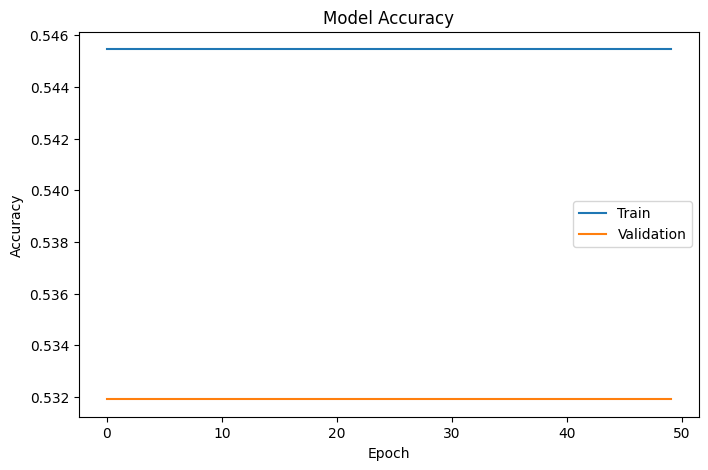

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

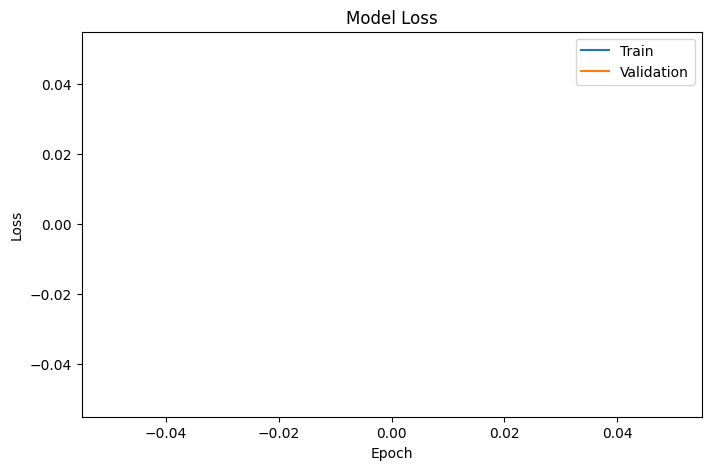

In [35]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()